In [3]:
from the_well.data import WellDataset
from einops import rearrange
import matplotlib.pyplot as plt
import numpy as np
from the_well.data.datamodule import WellDataModule

In [4]:
dataset_path = "datasets/permalloy_thin_film_switching"

In [6]:
data = WellDataModule(
    well_base_path=dataset_path,
    batch_size=4,
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False,
)

TypeError: WellDataModule.__init__() missing 1 required positional argument: 'well_dataset_name'

In [12]:
dataset_path = "datasets/permalloy_thin_film_switching"

In [24]:
dataset = WellDataset(
    path=dataset_path,
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False,
)

In [25]:
item = dataset[0]

list(item.keys())

['input_fields',
 'output_fields',
 'constant_scalars',
 'boundary_conditions',
 'space_grid',
 'input_time_grid',
 'output_time_grid']

In [26]:
item["input_fields"].shape

torch.Size([4, 100, 25, 3])

In [27]:
item["output_fields"].shape

torch.Size([1, 100, 25, 3])

In [29]:
dataset.metadata.field_names

{0: ['mx', 'my', 'mz'], 1: [], 2: []}

In [30]:
field_names = [
    name for group in dataset.metadata.field_names.values() for name in group
]
field_names

['mx', 'my', 'mz']

In [31]:
window_size = dataset.n_steps_input + dataset.n_steps_output

total_windows = 0
for i in range(dataset.metadata.n_files):
    windows_per_trajectory = (
        dataset.metadata.n_steps_per_trajectory[i] - window_size + 1
    )
    total_windows += (
        windows_per_trajectory * dataset.metadata.n_trajectories_per_file[i]
    )

print(total_windows)

776


In [32]:
len(dataset)

776

In [33]:
F = dataset.metadata.n_fields

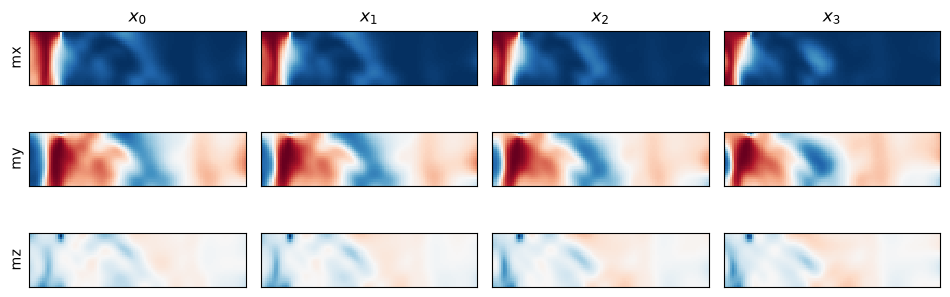

In [42]:
x = dataset[42]["input_fields"]
x = rearrange(x, "T Lx Ly F -> F T Lx Ly")

fig, axs = plt.subplots(F, 4, figsize=(4 * 2.4, F * 1.2))

for field in range(F):
    vmin = -1
    vmax = 1

    axs[field, 0].set_ylabel(f"{field_names[field]}")

    for t in range(4):
        axs[field, t].imshow(
            x[field, t].T, cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax
        )
        axs[field, t].set_xticks([])
        axs[field, t].set_yticks([])

        axs[0, t].set_title(f"$x_{t}$")

plt.tight_layout()